## Evaluate

In [1]:
from datasets import load_dataset, Video

ds = load_dataset("1rsh/mtp-ii-reels", split="train")

Resolving data files:   0%|          | 0/268 [00:00<?, ?it/s]

In [2]:
ds = ds.cast_column("video", Video(decode=False))

In [3]:
import instructor
from openai import AsyncOpenAI
from pydantic import BaseModel, Field

class Evaluation(BaseModel):
    verdict_correct: bool = Field(...)
    score: int = Field(ge=0, le=3)
    reasoning: str = Field(..., description="reasoning for assigning score in this case")

client = instructor.patch(AsyncOpenAI())

def evaluate_result(prediction, ground_truth):
  return client.chat.completions.create(
    model="gpt-4o-mini",
    temperature=0.0,
    response_model=Evaluation,
    messages=[
        {
            "role": "system",
            "content": """You are a strict evaluation model for content moderation outputs.

Your task is to evaluate a model's prediction against ground truth.

SCORING RULES:

0 → Verdict incorrect AND no relevant argument present
1 → Verdict incorrect BUT relevant argument present
2 → Verdict correct BUT reasoning is NOT similar to ground truth cues
3 → Verdict correct AND reasoning is similar to ground truth cues

DEFINITIONS:

- Relevant argument:
A reasoning point that correctly identifies a cue present in the ground truth reasoning,
even if the final verdict is wrong.

- Incorrect argument:
Reasoning that is generic or dismissive of the ground truth.

- Matching ground truth cues:
The reasoning explicitly captures somewhat similar implicit/explicit signals described in the ground truth, not just general safe interpretations.
"""
        },
        {
            "role": "user",
            "content": f"""
GROUND TRUTH: {ground_truth}

PREDICTION:
{prediction}
"""
        }
    ]
)


In [4]:
def display_video(video_dict):
    from IPython.display import Video as IPVideo
    return IPVideo(video_dict["path"], embed=True)

In [5]:
from classifier import VideoCaptioningModel

video_captioning_model = VideoCaptioningModel()

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

In [6]:
ds

Dataset({
    features: ['annotation', 'shareable_link', 'video', 'label'],
    num_rows: 267
})

In [ ]:
import json 
from tqdm.autonotebook import tqdm

from logger import logger
from classifier import classify_video

evals = []
correct = 0

for row in (pbar := tqdm(ds, desc="Evaluating videos")):
    path = row["video"]["path"]

    predicted_reasoning = await classify_video(video_captioning_model, path)

    logger.critical(f"Prediction: {predicted_reasoning.get('verdict', '')}")

    eval_result = await evaluate_result(
        prediction=predicted_reasoning,
        ground_truth={"verdict": row["label"], "reasoning": row["annotation"]}
    )

    logger.critical(f"Ground Truth: {eval_result.verdict_correct}, {eval_result.score}")

    correct += int(eval_result.verdict_correct)
    pbar.set_postfix({"accuracy": correct / (pbar.n + 1)})

    evals.append({"video": path, "eval": eval_result.model_dump(), "pred": predicted_reasoning, "ground_truth": row["annotation"]})

    with open("eval_results_fps_2.json", "w") as f:
        json.dump(evals, f, indent=2)

Evaluating videos:   0%|          | 0/10 [00:00<?, ?it/s]

[2026-04-24 19:57:46,625] — (INFO) — Evaluating video at /Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/frisky-hallowed-pig.mp4 using external classifier...


qwen-vl-utils using torchcodec to read video.


[2026-04-24 19:58:12,297] — (INFO) — Classification completed in 25.67 seconds.
[2026-04-24 19:58:12,298] — (CRITICAL) — Prediction: ContentLevel.SAFE
[2026-04-24 19:58:14,646] — (CRITICAL) — Ground Truth: False, 0
[2026-04-24 19:58:14,651] — (INFO) — Evaluating video at /Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/simple-bull-of-attack.mp4 using external classifier...
[2026-04-24 19:58:36,555] — (INFO) — Classification completed in 21.90 seconds.
[2026-04-24 19:58:36,557] — (CRITICAL) — Prediction: ContentLevel.SAFE
[2026-04-24 19:58:38,395] — (CRITICAL) — Ground Truth: False, 0
[2026-04-24 19:58:38,402] — (INFO) — Evaluating video at /Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/invincible-perch-of-warranty.mp4 using external classifier...
[2026-04-24 19:59:05,940] — (INFO) — Classification completed in 27.54 seconds.

In [10]:
import time 
import json 
from tqdm.autonotebook import tqdm

from logger import logger
from classifier import classify_video

fpses = [1, 2, 4, 6, 8]
evals = {fps: [] for fps in fpses}
correct = {fps: 0 for fps in fpses}

for row in (pbar := tqdm(ds.shuffle(seed=4103).select(range(25)), desc="Evaluating videos")):
    path = row["video"]["path"]

    for fps in fpses:
        video_captioning_model.video_fps = fps
        start_time = time.time()
        predicted_reasoning = await classify_video(video_captioning_model, path)
        end_time = time.time()

        logger.critical(f"Prediction: {predicted_reasoning.get('verdict', '')}")
        
        
        eval_result = await evaluate_result(
            prediction=predicted_reasoning,
            ground_truth={"verdict": row["label"], "reasoning": row["annotation"]}
        )

        logger.critical(f"Ground Truth: {eval_result.verdict_correct}, {eval_result.score}")

        correct[fps] += int(eval_result.verdict_correct)
        pbar.set_postfix({"accuracy": {fps: f"{correct[fps] / (pbar.n + 1):.2%}" for fps in fpses}})

        evals[fps].append({"video": path, "eval": {**eval_result.model_dump(), "latency": end_time - start_time}, "pred": predicted_reasoning, "ground_truth": row["annotation"]})

        with open(f"eval_results_fps_{fps}.json", "w") as f:
            json.dump(evals[fps], f, indent=2)

Evaluating videos:   0%|          | 0/25 [00:00<?, ?it/s]

[2026-04-24 20:24:16,670] — (INFO) — Evaluating video at /Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/opalescent-ambitious-grebe.mp4 using external classifier...
[2026-04-24 20:24:46,668] — (INFO) — Classification completed in 30.00 seconds.
[2026-04-24 20:24:46,670] — (CRITICAL) — Prediction: ContentLevel.IMPLICIT_SEXUAL
[2026-04-24 20:24:49,412] — (CRITICAL) — Ground Truth: True, 1
[2026-04-24 20:24:49,414] — (INFO) — Evaluating video at /Users/irsh/.cache/huggingface/hub/datasets--1rsh--mtp-ii-reels/snapshots/0a3ddc9531713194fc8a7d00f637e359078adc5e/train/implicit/opalescent-ambitious-grebe.mp4 using external classifier...
[2026-04-24 20:25:08,785] — (INFO) — Classification completed in 19.37 seconds.
[2026-04-24 20:25:08,786] — (CRITICAL) — Prediction: ContentLevel.IMPLICIT_SEXUAL
[2026-04-24 20:25:11,041] — (CRITICAL) — Ground Truth: True, 1
[2026-04-24 20:25:11,046] — (INFO) — Evaluating video at

In [11]:
for fps in fpses:
    temp_evals = []
    for eval in evals[fps]:
        temp_eval = eval.copy()
        if eval['eval']['verdict_correct'] == True and eval['eval']['score'] // 2 == 0:
            temp_eval['eval']['score'] += 2
        temp_evals.append(temp_eval)

    evals[fps] = temp_evals

    with open(f"eval_results_fps_{fps}.json", "w") as f:
        json.dump(evals[fps], f, indent=2)

## Results

In [ ]:
import matplotlib.pyplot as plt

def plot_score_distribution(scores, title=None):
    # Histogram with spacing
    counts, bins, patches = plt.hist(
        scores,
        bins=[-0.5, 0.5, 1.5, 2.5, 3.5],
        edgecolor='black',
        rwidth=0.6   # <-- controls gap (smaller = more space)
    )

    # Custom x-ticks
    plt.xticks(
        [0, 1, 2, 3],
        ["0: not(V) and not(R)", "1: not(V) but R", "2: V but not(R)", "3: V and R"]
    )

    # Add labels on bars
    for count, patch in zip(counts, patches):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(x, y, f"{int(count) / len(scores):.2%}", ha='center', va='bottom')

    plt.title("Evaluation Score Distribution" + (f" ({title})" if title else ""))
    plt.xlabel("Score Type")
    plt.ylabel("Count")
    plt.show()

In [28]:

def plot_reasoning_correctness(scores, title=None):
    vals = [s % 2 for s in scores]

    # Histogram with proper bins + spacing
    counts, bins, patches = plt.hist(
        vals,
        bins=[-0.5, 0.5, 1.5],
        edgecolor='black',
        rwidth=0.6
    )

    # X labels
    plt.xticks([0, 1], ["Incorrect Reasoning", "Correct Reasoning"])

    # Add counts on top
    for count, patch in zip(counts, patches):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(x, y, f"{int(count) / len(scores):.2%}", ha='center', va='bottom')

    plt.title("Reasoning Correctness Distribution" + (f" ({title})" if title else ""))
    plt.ylabel("Count")

    plt.show()

In [29]:
def plot_verdict_correctness(evals, title=None):
    vals = [e['eval']['verdict_correct'] for e in evals]

    # Histogram with proper bins + spacing
    counts, bins, patches = plt.hist(
        vals,
        bins=[-0.5, 0.5, 1.5],
        edgecolor='black',
        rwidth=0.6
    )

    # X labels
    plt.xticks([0, 1], ["Incorrect Verdict", "Correct Verdict"])

    # Add counts on top
    for count, patch in zip(counts, patches):
        x = patch.get_x() + patch.get_width() / 2
        y = patch.get_height()
        plt.text(x, y, f"{int(count) / len(scores):.2%}", ha='center', va='bottom')

    plt.title("Verdict Correctness Distribution" + (f" ({title})" if title else ""))
    plt.ylabel("Count")

    plt.show()

In [33]:
import numpy as np

def plot_confusion_matrix(evals, precision_label, title=None):
    confusion_matrix = {
        "TP": sum([1 for e in evals if e['eval']['verdict_correct'] == True and e['ground_truth_label'] == precision_label]),
        "FP": sum([1 for e in evals if e['eval']['verdict_correct'] == True and e['ground_truth_label'] != precision_label]),
        "TN": sum([1 for e in evals if e['eval']['verdict_correct'] == False and e['ground_truth_label'] != precision_label]),
        "FN": sum([1 for e in evals if e['eval']['verdict_correct'] == False and e['ground_truth_label'] == precision_label]),
    }

    cm = np.array([
        [confusion_matrix["TP"], confusion_matrix["FP"]],
        [confusion_matrix["FN"], confusion_matrix["TN"]]
    ])

    total = cm.sum()
    cm_pct = cm / total * 100  # overall percentage

    plt.imshow(cm, cmap='Blues')

    # Axis labels
    plt.xticks([0, 1], [f"Predicted Positive", f"Predicted Negative"])
    plt.yticks([0, 1], [f"True", f"False"])

    # Annotate cells with count + percentage
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)",
                ha='center', va='center',
                color='black'
            )

    plt.colorbar(label='Count')
    plt.title(f"Confusion Matrix for {precision_label} Class" + (f" ({title})" if title else ""))
    plt.tight_layout()
    plt.show()

In [32]:
# precision_label = "SAFE"
precision_label = "IMPLICIT_SEXUAL"

--------------------Classification Results--------------------
Overall Accuracy: 62.80%
Precision for IMPLICIT_SEXUAL class: 71.18%
Reasoning Precision for IMPLICIT_SEXUAL class: 35.88%


/Users/irsh/Documents/workdir/academic/mtp/agentic/.venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


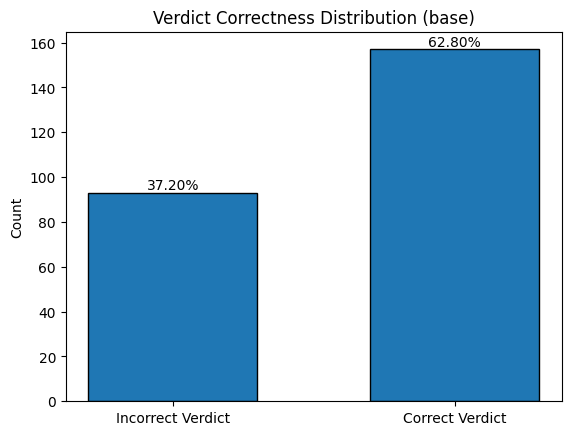

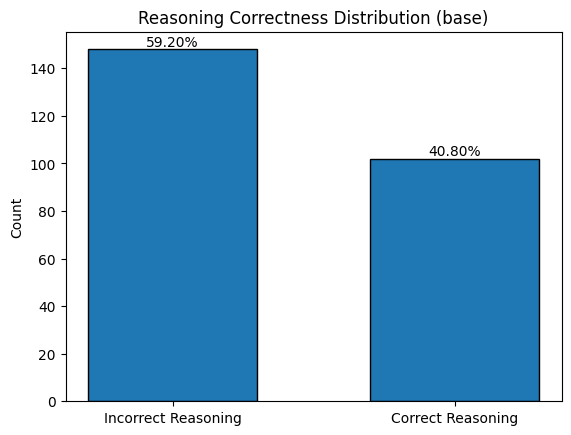

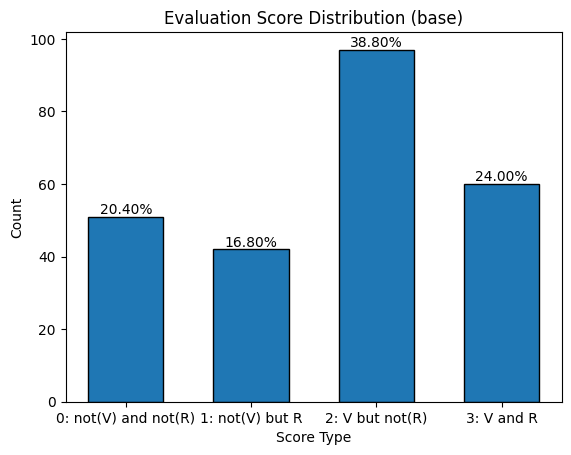

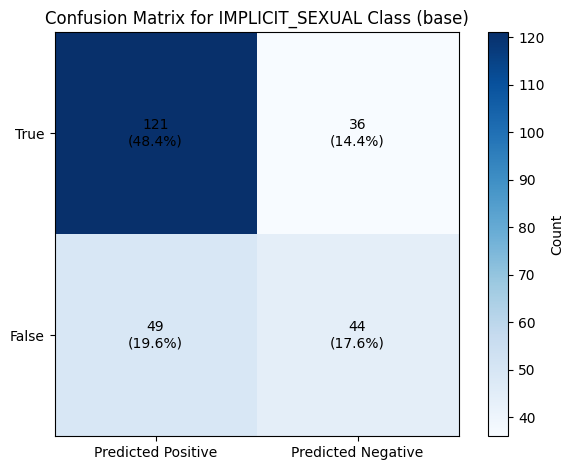

In [36]:
import json

with open("eval_results/eval_results_base.json", "r") as f:
    evals = json.load(f)
    
temp_evals = []
for eval in evals:
    temp_eval = eval.copy()
    if eval['eval']['verdict_correct'] == True and eval['eval']['score'] // 2 == 0:
        temp_eval['eval']['score'] += 2
    temp_evals.append(temp_eval)

evals = temp_evals

evals = [{**e, 'ground_truth_label': "IMPLICIT_SEXUAL" if "implicit" in e['video'] else "SAFE"} for e in evals]
scores = [eval['eval']['score'] for eval in evals]

print("-" * 20 + "Classification Results" + "-" * 20)

accuracy = sum([e['eval']['verdict_correct'] for e in evals]) / len(evals)
print(f"Overall Accuracy: {accuracy:.2%}")

precision = sum([e['eval']['verdict_correct'] == True for e in evals if e['ground_truth_label'] == "IMPLICIT_SEXUAL"]) / sum([1 for e in evals if e['ground_truth_label'] == "IMPLICIT_SEXUAL"])
print(f"Precision for {precision_label} class: {precision:.2%}")

reasoning_precision = sum([e['eval']['score'] % 2 == 1 for e in evals if e['ground_truth_label'] == precision_label]) / sum([1 for e in evals if e['ground_truth_label'] == precision_label])
print(f"Reasoning Precision for {precision_label} class: {reasoning_precision:.2%}")

plot_verdict_correctness(evals, title="base")
plot_reasoning_correctness(scores, title="base")
plot_score_distribution(scores, title="base")
plot_confusion_matrix(evals, precision_label, title="base")

--------------------Classification Results--------------------
Overall Accuracy: 61.07%
Precision for IMPLICIT_SEXUAL class: 61.18%
Reasoning Precision for IMPLICIT_SEXUAL class: 41.76%


/Users/irsh/Documents/workdir/academic/mtp/agentic/.venv/lib/python3.11/site-packages/matplotlib/axes/_axes.py:7132: RuntimeWarning: Converting input from bool to <class 'numpy.uint8'> for compatibility.
  m, bins = np.histogram(x[i], bins, weights=w[i], **hist_kwargs)


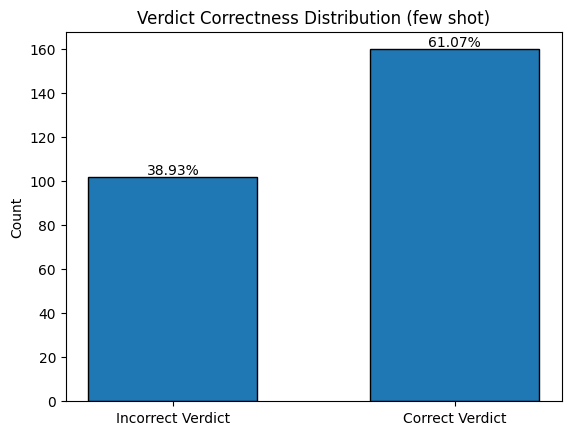

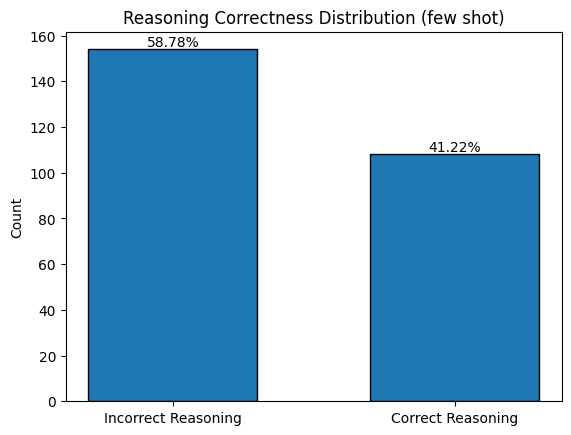

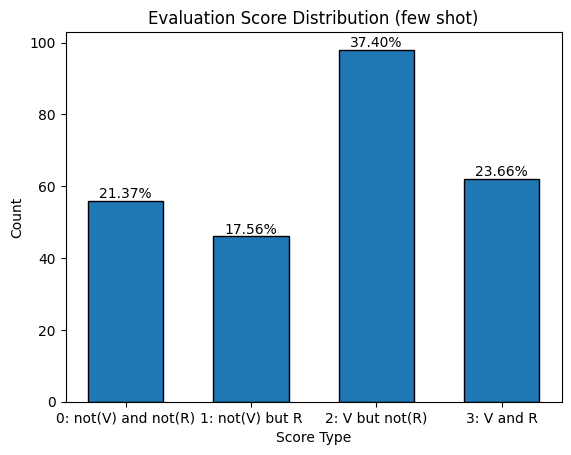

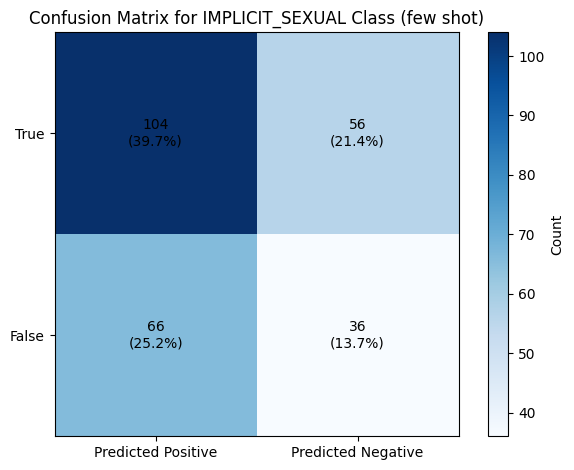

In [ ]:
with open("eval_results/eval_results_few_shot.json", "r") as f:
    evals = json.load(f)
    
temp_evals = []
for eval in evals:
    temp_eval = eval.copy()
    if eval['eval']['verdict_correct'] == True and eval['eval']['score'] // 2 == 0:
        temp_eval['eval']['score'] += 2
    temp_evals.append(temp_eval)

evals = temp_evals

evals = [{**e, 'ground_truth_label': "IMPLICIT_SEXUAL" if "implicit" in e['video'] else "SAFE"} for e in evals]
scores = [eval['eval']['score'] for eval in evals]

print("-" * 20 + "Classification Results" + "-" * 20)

accuracy = sum([e['eval']['verdict_correct'] for e in evals]) / len(evals)
print(f"Overall Accuracy: {accuracy:.2%}")

precision = sum([e['eval']['verdict_correct'] == True for e in evals if e['ground_truth_label'] == "IMPLICIT_SEXUAL"]) / sum([1 for e in evals if e['ground_truth_label'] == "IMPLICIT_SEXUAL"])
print(f"Precision for {precision_label} class: {precision:.2%}")

reasoning_precision = sum([e['eval']['score'] % 2 == 1 for e in evals if e['ground_truth_label'] == precision_label]) / sum([1 for e in evals if e['ground_truth_label'] == precision_label])
print(f"Reasoning Precision for {precision_label} class: {reasoning_precision:.2%}")

plot_verdict_correctness(evals, title="few shot")
plot_reasoning_correctness(scores, title="few shot")
plot_score_distribution(scores, title="few shot")
plot_confusion_matrix(evals, precision_label, title="few shot")

In [48]:
# evals = {fps: [{**e, 'ground_truth_label': "IMPLICIT_SEXUAL" if "implicit" in e['video'] else "SAFE"} for e in evals[fps]] for fps in fpses}
# scores = {fps: [eval['eval']['score'] for eval in evals[fps]] for fps in fpses}
results = {}
evals = {}
scores = {}
fpses = [1, 2, 4, 6, 8]

for fps in fpses:
    with open(f"eval_results/eval_results_fps_{fps}.json") as f:
        eval = json.load(f)
    
    temp_evals = []
    for e in eval:
        temp_eval = e.copy()
        if e['eval']['verdict_correct'] == True and e['eval']['score'] // 2 == 0:
            temp_eval['eval']['score'] += 2
        temp_evals.append(temp_eval)

    eval = temp_evals

    eval = [{**e, 'ground_truth_label': "IMPLICIT_SEXUAL" if "implicit" in e['video'] else "SAFE"} for e in eval]
    score = [e['eval']['score'] for e in eval]

    evals[fps] = eval
    scores[fps] = score


    print("-" * 20 + f"Classification Results for {fps}" + "-" * 20)

    accuracy = sum([e['eval']['verdict_correct'] for e in eval]) / len(eval)
    print(f"Overall Accuracy: {accuracy:.2%}")

    precision = sum([e['eval']['verdict_correct'] == True for e in eval if e['ground_truth_label'] == "IMPLICIT_SEXUAL"]) / sum([1 for e in eval if e['ground_truth_label'] == "IMPLICIT_SEXUAL"])
    print(f"Precision for {precision_label} class: {precision:.2%}")

    reasoning_precision = sum([e['eval']['score'] % 2 == 1 for e in eval if e['ground_truth_label'] == precision_label]) / sum([1 for e in eval if e['ground_truth_label'] == precision_label])
    print(f"Reasoning Precision for {precision_label} class: {reasoning_precision:.2%}")

    results[fps] = {
        "accuracy": accuracy,
        "precision": precision,
        "reasoning_precision": reasoning_precision
    }

--------------------Classification Results for 1--------------------
Overall Accuracy: 60.00%
Precision for IMPLICIT_SEXUAL class: 71.43%
Reasoning Precision for IMPLICIT_SEXUAL class: 28.57%
--------------------Classification Results for 2--------------------
Overall Accuracy: 60.00%
Precision for IMPLICIT_SEXUAL class: 64.29%
Reasoning Precision for IMPLICIT_SEXUAL class: 50.00%
--------------------Classification Results for 4--------------------
Overall Accuracy: 68.00%
Precision for IMPLICIT_SEXUAL class: 78.57%
Reasoning Precision for IMPLICIT_SEXUAL class: 28.57%
--------------------Classification Results for 6--------------------
Overall Accuracy: 64.00%
Precision for IMPLICIT_SEXUAL class: 71.43%
Reasoning Precision for IMPLICIT_SEXUAL class: 35.71%
--------------------Classification Results for 8--------------------
Overall Accuracy: 64.00%
Precision for IMPLICIT_SEXUAL class: 64.29%
Reasoning Precision for IMPLICIT_SEXUAL class: 42.86%


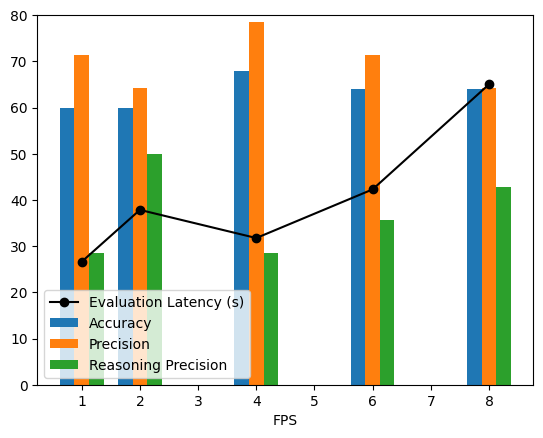

In [49]:
plt.bar([f-0.25 for f in fpses], [r['accuracy'] * 100 for r in results.values()], width=0.25, label="Accuracy")
plt.bar(fpses, [r['precision'] * 100 for r in results.values()], width=0.25, label="Precision")
plt.bar([f+0.25 for f in fpses], [r['reasoning_precision'] * 100 for r in results.values()], width=0.25, label="Reasoning Precision")
plt.plot([f for f in fpses], [sum([eval['eval']['latency'] for eval in evals[fps]]) / len(evals[fps]) for fps in fpses], label="Evaluation Latency (s)", color='black', marker='o')

plt.xlabel("FPS")

plt.legend(loc="lower left")
plt.ylim(0, 80)
plt.show()

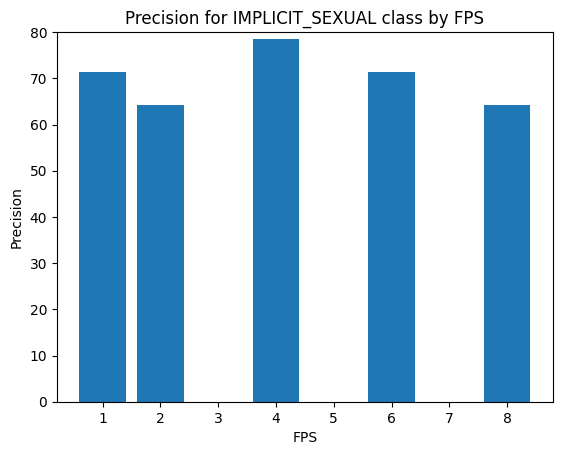

In [50]:
plt.bar(results.keys(), [r['precision'] * 100 for r in results.values()])
plt.title(f"Precision for {precision_label} class by FPS")
plt.xlabel("FPS")
plt.ylabel("Precision")
plt.ylim(0, 80)
plt.show()

## Agent Evolution

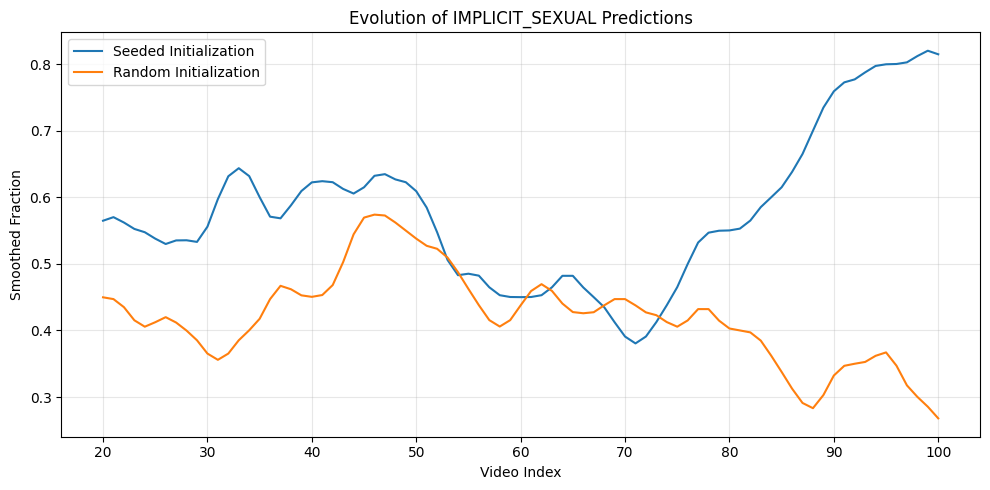

In [119]:
import json
import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import gaussian_filter1d

# ---- Load data ----
with open("experiments/agent_evolution_seed.json", "r") as f:
    seeded = json.load(f)

with open("experiments/agent_evolution_rand.json", "r") as f:
    random_init = json.load(f)

window_size = 20

def smooth_evolution(evolution, window_size=window_size, sigma=1):
    # ---- Convert to binary (1 = IMPLICIT_SEXUAL, 0 = otherwise) ----
    binary = np.array([
        1 if e['result']['verdict'] == "IMPLICIT_SEXUAL" else 0
        for e in evolution
    ])

    # ---- Windowed fraction ----
    windowed = np.convolve(binary, np.ones(window_size) / window_size, mode='valid')

    # ---- Smooth ----
    smoothed = gaussian_filter1d(windowed, sigma=sigma)

    return smoothed

seed_smoothed = smooth_evolution(seeded)
rand_smoothed = smooth_evolution(random_init)

# ---- Plot ----
plt.figure(figsize=(10, 5))
plt.plot(range(window_size, len(seed_smoothed) + window_size), seed_smoothed, label=f"Seeded Initialization")
plt.plot(range(window_size, len(rand_smoothed) + window_size), rand_smoothed, label=f"Random Initialization")
plt.title("Evolution of IMPLICIT_SEXUAL Predictions")
plt.xlabel("Video Index")
plt.ylabel("Smoothed Fraction")
plt.legend()


plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

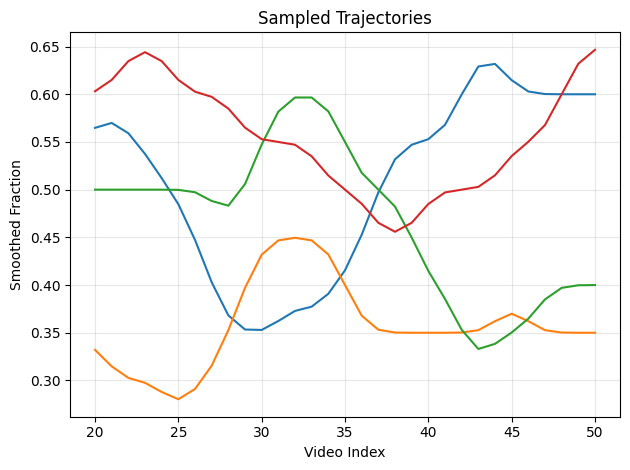

In [158]:
import os

folder = "experiments/trajectory/"

window_size = 20
cumulative = False

# plt.figure(figsize=(10, 5))

for filepath in os.listdir(folder):
    try:
        if not filepath.endswith(".json"):
            continue 

        filepath = folder + filepath 
        with open(filepath, "r") as f:
            data = json.load(f)

        data = smooth_evolution(data, window_size)

        if cumulative:
            data = [sum(data[:i]) for i in range(len(data))]

        plt.plot(range(window_size, len(data) + window_size), data)
    except:
        continue

plt.title("Sampled Trajectories")
plt.xlabel("Video Index")
plt.ylabel("Smoothed Fraction")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()